# CNN group-aware con los siete archivos RRUFF verificados

Cuarta etapa. Conserva el benchmark group-aware de excellent_unoriented para la construcción del conjunto de test y añade al entrenamiento información auxiliar procedente de los siete dominios, después de auditar duplicados y solapamientos de fuente. Es el puente directo entre los prototipos iniciales y los experimentos finales multisemilla.

- Utiliza la misma CNN del Notebook 01.
- Utiliza los 7 ZIPs de la base de datos RUUFF para la construcción del training set.
- Utiliza la misma técnica de Aumentación que el notebook 03.
- Utiliza el mismo criterio de auditoría de datos que el notebook 02, con el fin de asegurar independencia de fuentes.
- El test set sigue utilizando espectros del dominio Excellent Unoriented.

## Lugar dentro de la progresión experimental

Este notebook se conserva como evidencia de desarrollo y comparación. Debe ejecutarse desde un kernel limpio para generar sus resultados; no contiene métricas heredadas. Su propósito es mostrar qué problema metodológico se identifica en esta etapa y cómo conduce al siguiente experimento. Los resultados finales del TFM proceden de los notebooks con split fijo y cinco semillas.


Este notebook lee los TXT directamente desde los ZIP y muestra resultados inline. No exporta archivos ni crea carpetas de resultados.

## Importaciones y reproducibilidad

Se cargan las bibliotecas necesarias y se fijan las semillas aleatorias disponibles. La celda también informa de las versiones principales y de la disponibilidad de GPU. Fijar semillas reduce variaciones accidentales, aunque una única ejecución todavía no permite medir toda la variabilidad del entrenamiento; esa limitación se resuelve posteriormente en los notebooks finales de cinco semillas.


In [1]:
import os, re, json, random, zipfile, platform, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from scipy.interpolate import interp1d
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    log_loss, accuracy_score, top_k_accuracy_score,
    precision_recall_fscore_support, classification_report,
    confusion_matrix,
)
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print("Python:", platform.python_version())
print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Devices:", tf.config.list_physical_devices())
print("✓ Reproducibility configured")
# Modo solo pantalla: no se escriben resultados en disco.
def _mostrar_en_pantalla(obj, destino=None, *args, **kwargs):
    nombre = str(destino) if destino is not None else "salida tabular"
    print(f"\n[SOLO PANTALLA] {nombre} | dimensiones: {getattr(obj, 'shape', None)}")
    try:
        display(obj if len(obj) <= 40 else obj.head(40))
    except Exception:
        print(obj)

pd.DataFrame.to_csv = lambda self, path_or_buf=None, *a, **k: _mostrar_en_pantalla(self, path_or_buf)
pd.Series.to_csv = lambda self, path_or_buf=None, *a, **k: _mostrar_en_pantalla(self, path_or_buf)
np.save = lambda destino, datos, *a, **k: _mostrar_en_pantalla(pd.DataFrame(np.atleast_1d(datos)), destino)
plt.savefig = lambda destino, *a, **k: print(f"[SOLO PANTALLA] Figura mostrada; no se guarda {destino}")
from matplotlib.figure import Figure
Figure.savefig = lambda self, destino, *a, **k: print(f"[SOLO PANTALLA] Figura mostrada; no se guarda {destino}")
Path.write_text = lambda self, data, *a, **k: print(f"[SOLO PANTALLA] {self.name}:\n{str(data)[:4000]}") or len(str(data))

class ZipMember:
    """Referencia ligera a un TXT dentro de un ZIP, sin extracción a disco."""
    def __init__(self, archive_path, member):
        self.archive_path, self.member = Path(archive_path), member
    @property
    def name(self): return Path(self.member).name
    def read_bytes(self):
        with zipfile.ZipFile(self.archive_path) as zf: return zf.read(self.member)
    def __str__(self): return f"{self.archive_path.name}::{self.member}"
    def __repr__(self): return str(self)

def open_spectrum(member):
    import io
    return io.StringIO(member.read_bytes().decode("utf-8", errors="replace"))


Python: 3.11.15
TensorFlow: 2.21.0
NumPy: 2.4.6
Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
✓ Reproducibility configured


## Configuración del experimento

Aquí se concentran las rutas, criterios mínimos de inclusión, tamaño de la cuadrícula Raman y parámetros de entrenamiento. Separar la configuración de la lógica facilita la reproducibilidad y permite identificar qué cambia entre etapas. Los umbrales no deben ajustarse mirando el test: cualquier decisión de diseño debe tomarse con información de entrenamiento y validación.


In [2]:
BENCHMARK_ZIP_FILENAME = "excellent_unoriented.zip"
REQUIRED_ZIP_FILENAMES = [
    "excellent_unoriented.zip",
    "poor_unoriented.zip",
    "unrated_oriented.zip",
    "unrated_unoriented.zip",
    "excellent_oriented.zip",
    "fair_oriented.zip",
    "fair_unoriented.zip",
]
ARCHIVE_SEARCH_DIRS = [Path.cwd(), Path.cwd() / "upload", Path("/content")]

WORK_DIR = Path("raman_group_aware_all_7_zips_verified")
EXTRACT_ROOT = WORK_DIR / "extracted"
RESULTS_DIR = WORK_DIR / "results"

MIN_CLASS_COUNT = 5
MIN_SOURCE_GROUPS = 3
REQUIRE_RELIABLE_SOURCE_IDS = True
N_GRID_POINTS = 512
COVERAGE_FRACTION = 0.95
MAX_EPOCHS = 150
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
EARLY_STOPPING_PATIENCE = 15
LR_PATIENCE = 6

MAX_SHIFT_POINTS = 3
SHIFT_PROBABILITY = 0.70
MAX_NOISE_STD = 0.01
NOISE_PROBABILITY = 0.70


config = {
    "seed": SEED,
    "benchmark_archive": BENCHMARK_ZIP_FILENAME,
    "required_archives": REQUIRED_ZIP_FILENAMES,
    "archive_policy": "exact seven-file manifest; presence, integrity, text-file count, and parsed count verified",
    "evaluation_domain": "excellent_unoriented only",
    "auxiliary_data_policy": "training only; retained benchmark classes only; exclude benchmark validation/test sources",
    "min_class_count": MIN_CLASS_COUNT, "min_source_groups": MIN_SOURCE_GROUPS,
    "require_reliable_source_ids": REQUIRE_RELIABLE_SOURCE_IDS,
    "n_grid_points": N_GRID_POINTS, "coverage_fraction": COVERAGE_FRACTION,
    "max_epochs": MAX_EPOCHS, "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "lr_patience": LR_PATIENCE,
    "augmentation": {
        "training_only": True,
        "max_shift_points": MAX_SHIFT_POINTS,
        "shift_probability": SHIFT_PROBABILITY,
        "max_noise_std": MAX_NOISE_STD,
        "noise_probability": NOISE_PROBABILITY,
        "edge_handling": "nearest edge value; no circular wrap and no zero padding",
        "renormalize_after_augmentation": True,
    },
}
(RESULTS_DIR / "config.json").write_text(json.dumps(config, indent=2))
print("✓ Configuración mostrada en pantalla")


[SOLO PANTALLA] config.json:
{
  "seed": 42,
  "benchmark_archive": "excellent_unoriented.zip",
  "required_archives": [
    "excellent_unoriented.zip",
    "poor_unoriented.zip",
    "unrated_oriented.zip",
    "unrated_unoriented.zip",
    "excellent_oriented.zip",
    "fair_oriented.zip",
    "fair_unoriented.zip"
  ],
  "archive_policy": "exact seven-file manifest; presence, integrity, text-file count, and parsed count verified",
  "evaluation_domain": "excellent_unoriented only",
  "auxiliary_data_policy": "training only; retained benchmark classes only; exclude benchmark validation/test sources",
  "min_class_count": 5,
  "min_source_groups": 3,
  "require_reliable_source_ids": true,
  "n_grid_points": 512,
  "coverage_fraction": 0.95,
  "max_epochs": 150,
  "batch_size": 32,
  "learning_rate": 0.001,
  "early_stopping_patience": 15,
  "lr_patience": 6,
  "augmentation": {
    "training_only": true,
    "max_shift_points": 3,
    "shift_probability": 0.7,
    "max_noise_std": 0.0

## Localización y extracción de los datos

La celda busca únicamente los archivos previstos por el experimento y los extrae en directorios controlados. Esta comprobación evita mezclar accidentalmente versiones o dominios de RRUFF. La procedencia de cada espectro se conserva en el manifiesto para que pueda auditarse en las etapas posteriores.


In [3]:
import hashlib
import shutil

def slug_from_archive(path):
    slug = re.sub(r"[^a-z0-9]+", "_", path.stem.lower()).strip("_")
    return slug or "archive"

def resolve_required_archives():
    resolved = {}
    duplicate_locations = {}
    for filename in REQUIRED_ZIP_FILENAMES:
        matches = [
            (folder / filename).resolve()
            for folder in ARCHIVE_SEARCH_DIRS
            if (folder / filename).is_file()
        ]
        if matches:
            resolved[filename] = matches[0]
            if len(matches) > 1:
                duplicate_locations[filename] = [str(path) for path in matches]
    missing = [name for name in REQUIRED_ZIP_FILENAMES if name not in resolved]
    if missing:
        raise FileNotFoundError(
            "Missing required Raman archives: " + ", ".join(missing) +
            ". Put them beside the notebook, in upload/, or in /content."
        )
    if duplicate_locations:
        print("Note: duplicate archive locations found; using the first search-directory match:")
        print(json.dumps(duplicate_locations, indent=2))
    return resolved

resolved_archives = resolve_required_archives()
archive_specs = [
    (slug_from_archive(Path(filename)), resolved_archives[filename])
    for filename in REQUIRED_ZIP_FILENAMES
]

archive_inventory = pd.DataFrame([
    {
        "dataset_subset": subset,
        "zip_filename": path.name,
        "zip_path": str(path),
        "role": "benchmark_train_validation_test" if subset == "excellent_unoriented" else "auxiliary_training_only",
    }
    for subset, path in archive_specs
])
archive_inventory.to_csv(RESULTS_DIR / "archive_inventory.csv", index=False)
display(archive_inventory)

file_entries = []
archive_file_counts = []
for dataset_subset, zip_path in archive_specs:
    with zipfile.ZipFile(zip_path) as archive:
        members = sorted(n for n in archive.namelist() if n.lower().endswith(".txt"))
    if not members:
        raise RuntimeError(f"{zip_path.name} no contiene espectros .txt.")
    subset_files = [ZipMember(zip_path, member) for member in members]
    file_entries.extend((path, dataset_subset) for path in subset_files)
    archive_file_counts.append({"dataset_subset": dataset_subset, "zip_filename": zip_path.name, "text_files": len(subset_files)})
    print(f"{dataset_subset}: {len(subset_files)} TXT leídos directamente de {zip_path.name}")

# Los duplicados exactos se detectan sobre los bytes internos, sin extraerlos.
seen_hashes, unique_entries, duplicate_rows = {}, [], []
for path, dataset_subset in file_entries:
    digest = hashlib.sha256(path.read_bytes()).hexdigest()
    if digest in seen_hashes:
        kept_path, kept_subset = seen_hashes[digest]
        duplicate_rows.append({"excluded_filepath": str(path), "excluded_subset": dataset_subset,
                               "kept_filepath": str(kept_path), "kept_subset": kept_subset, "sha256": digest})
    else:
        seen_hashes[digest] = (path, dataset_subset)
        unique_entries.append((path, dataset_subset))

duplicate_table = pd.DataFrame(duplicate_rows)
display(duplicate_table.head(40))
filepaths = [path for path, _ in unique_entries]
dataset_by_path = {str(path): subset for path, subset in unique_entries}
print("Archivos TXT únicos:", len(filepaths))
print("Duplicados exactos excluidos:", len(duplicate_rows))
print("✓ ZIP leídos directamente; no se crearon carpetas de extracción")



[SOLO PANTALLA] raman_group_aware_all_7_zips_verified/results/archive_inventory.csv | dimensiones: (7, 4)


,dataset_subset,zip_filename,zip_path,role
0,excellent_unoriented,excellent_unoriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/exce...,benchmark_train_validation_test
1,poor_unoriented,poor_unoriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/poor...,auxiliary_training_only
2,unrated_oriented,unrated_oriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/unra...,auxiliary_training_only
3,unrated_unoriented,unrated_unoriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/unra...,auxiliary_training_only
4,excellent_oriented,excellent_oriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/exce...,auxiliary_training_only
5,fair_oriented,fair_oriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/fair...,auxiliary_training_only
6,fair_unoriented,fair_unoriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/fair...,auxiliary_training_only


,dataset_subset,zip_filename,zip_path,role
0,excellent_unoriented,excellent_unoriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/exce...,benchmark_train_validation_test
1,poor_unoriented,poor_unoriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/poor...,auxiliary_training_only
2,unrated_oriented,unrated_oriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/unra...,auxiliary_training_only
3,unrated_unoriented,unrated_unoriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/unra...,auxiliary_training_only
4,excellent_oriented,excellent_oriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/exce...,auxiliary_training_only
5,fair_oriented,fair_oriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/fair...,auxiliary_training_only
6,fair_unoriented,fair_unoriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/fair...,auxiliary_training_only


excellent_unoriented: 11415 TXT leídos directamente de excellent_unoriented.zip
poor_unoriented: 1639 TXT leídos directamente de poor_unoriented.zip
unrated_oriented: 3778 TXT leídos directamente de unrated_oriented.zip
unrated_unoriented: 639 TXT leídos directamente de unrated_unoriented.zip
excellent_oriented: 7668 TXT leídos directamente de excellent_oriented.zip
fair_oriented: 25 TXT leídos directamente de fair_oriented.zip
fair_unoriented: 2951 TXT leídos directamente de fair_unoriented.zip


,excluded_filepath,excluded_subset,kept_filepath,kept_subset,sha256
0,unrated_oriented.zip::Diopside__R060085-5__Ram...,unrated_oriented,unrated_oriented.zip::Diopside__R060085-5__Ram...,unrated_oriented,987441311db56eff755bdf183cb77a8fc87e22cf45a472...
1,unrated_oriented.zip::Lazulite__R050269-6__Ram...,unrated_oriented,unrated_oriented.zip::Lazulite__R050269-6__Ram...,unrated_oriented,cb2f44f6b851ef872b4ccd5a2d196f1eb84eacce763cfc...
2,unrated_oriented.zip::Levyne-Na__R060021-4__Ra...,unrated_oriented,unrated_oriented.zip::Levyne-Na__R060021-4__Ra...,unrated_oriented,bd9cde35a3a7ece7d6b0b82e859098e2489fcb2cf77e31...
3,unrated_oriented.zip::Levyne-Na__R060021-4__Ra...,unrated_oriented,unrated_oriented.zip::Levyne-Na__R060021-4__Ra...,unrated_oriented,e3693ab7a478cf1ac481b63dd3e5f848d61d9d4eda5101...
4,unrated_oriented.zip::Pyrope__R050446-3__Raman...,unrated_oriented,unrated_oriented.zip::Pyrope__R050446-3__Raman...,unrated_oriented,6cfde17d262493b899371a45698449e5a7e6d429324fe9...
5,unrated_unoriented.zip::Margarosanite__R120111...,unrated_unoriented,excellent_unoriented.zip::Margarosanite__R1201...,excellent_unoriented,82cca24642ab104d957d1125f37c3ecddf6069ebecc118...
6,unrated_unoriented.zip::Margarosanite__R120111...,unrated_unoriented,excellent_unoriented.zip::Margarosanite__R1201...,excellent_unoriented,b43350d5cb50e8aecb10e32dee0153b5f00c5151b4b315...
7,excellent_oriented.zip::Augite__R061086-4__Ram...,excellent_oriented,unrated_oriented.zip::Augite__R061086-4__Raman...,unrated_oriented,3215f776d3c8eb7489c874c26c1941caf143f6e8eb75d3...
8,excellent_oriented.zip::Baddeleyite__R060016-3...,excellent_oriented,excellent_oriented.zip::Baddeleyite__R060016-3...,excellent_oriented,426f0f31f6c1625b1daf383871926cba440399f61d381d...
9,excellent_oriented.zip::Calcite__R050009-3__Ra...,excellent_oriented,excellent_oriented.zip::Calcite__R050009-3__Ra...,excellent_oriented,17ad51cea7b9a9d245ed9dbcba04adea065f7285ce1283...


Archivos TXT únicos: 28099
Duplicados exactos excluidos: 16
✓ ZIP leídos directamente; no se crearon carpetas de extracción


## Lectura de espectros y construcción del manifiesto

Los archivos RRUFF pueden contener metadatos y separadores heterogéneos. El parser identifica pares numéricos de desplazamiento Raman e intensidad, ordena el eje y descarta registros que no permiten construir un espectro válido. El manifiesto conserva etiqueta, archivo, dominio e identificador de fuente cuando está disponible, proporcionando trazabilidad desde la predicción hasta el fichero original.


In [4]:
NUMBER = re.compile(r"[-+]?(?:\d+(?:\.\d*)?|\.\d+)(?:[Ee][-+]?\d+)?")
RRUFF_ID = re.compile(r"(?<![A-Za-z0-9])R\d{6,8}(?!\d)", re.IGNORECASE)

def mineral_from_filename(path):
    label = path.name.split("__")[0].strip()
    return label.replace("_", " ")

def unique_rruff_ids(text):
    return sorted({m.upper() for m in RRUFF_ID.findall(text)})

def load_spectrum_and_header(path):
    pairs, header_lines = [], []
    try:
        with open_spectrum(path) as handle:
            for line in handle:
                if line.lstrip().startswith("##"):
                    header_lines.append(line.strip())
                    continue
                if not line.strip():
                    continue
                values = NUMBER.findall(line)
                if len(values) >= 2:
                    try:
                        pairs.append((float(values[0]), float(values[1])))
                    except ValueError:
                        pass
        if len(pairs) < 10:
            return None, header_lines, "fewer than 10 numeric pairs"
        arr = np.asarray(pairs, dtype=np.float64)
        arr = arr[np.isfinite(arr[:, 0])]
        if len(arr) < 10:
            return None, header_lines, "too few finite Raman coordinates"
        if not np.isfinite(arr[:, 1]).all():
            return None, header_lines, "non-finite intensities"
        frame = pd.DataFrame({"shift": arr[:, 0], "intensity": arr[:, 1]})
        frame = frame.groupby("shift", as_index=False)["intensity"].mean().sort_values("shift")
        if len(frame) < 10 or frame["shift"].iloc[-1] <= frame["shift"].iloc[0]:
            return None, header_lines, "degenerate Raman axis"
        if np.max(np.abs(frame["intensity"].to_numpy())) <= 1e-12:
            return None, header_lines, "flat or effectively zero spectrum"
        spectrum = (frame["shift"].to_numpy(), frame["intensity"].to_numpy())
        return spectrum, header_lines, None
    except Exception as exc:
        return None, header_lines, f"parse error: {type(exc).__name__}"

records, parsed = [], {}
for i, path in enumerate(filepaths):
    dataset_subset = dataset_by_path[str(path)]
    result, header_lines, reason = load_spectrum_and_header(path)
    filename_ids = unique_rruff_ids(path.name)
    header_ids = unique_rruff_ids("\n".join(header_lines))
    candidate_ids = sorted(set(filename_ids) | set(header_ids))
    conflict = bool(filename_ids and header_ids and set(filename_ids) != set(header_ids))
    resolved_source_id = candidate_ids[0] if len(candidate_ids) == 1 and not conflict else None
    if conflict:
        source_status = "filename_header_conflict"
    elif len(candidate_ids) == 0:
        source_status = "missing"
    elif len(candidate_ids) > 1:
        source_status = "multiple_candidates"
    elif filename_ids and header_ids:
        source_status = "filename_header_agree"
    elif filename_ids:
        source_status = "filename_only"
    else:
        source_status = "header_only"

    label = mineral_from_filename(path)
    record = {
        "spectrum_id": f"S{i:06d}", "filepath": str(path), "filename": path.name,
        "dataset_subset": dataset_subset, "label": label, "accepted_parse": result is not None, "rejection_reason": reason,
        "source_id_filename": "|".join(filename_ids),
        "source_id_header": "|".join(header_ids),
        "source_id": resolved_source_id,
        "source_id_status": source_status,
    }
    if result is not None:
        shift, intensity = result
        record.update(n_points=len(shift), min_shift=float(shift.min()), max_shift=float(shift.max()))
        parsed[record["spectrum_id"]] = (shift, intensity)
    records.append(record)

manifest = pd.DataFrame(records)
source_audit = manifest[[
    "spectrum_id", "filepath", "dataset_subset", "label", "source_id_filename", "source_id_header",
    "source_id", "source_id_status", "accepted_parse"
]].copy()
source_audit.to_csv(RESULTS_DIR / "source_id_audit.csv", index=False)
manifest.to_csv(RESULTS_DIR / "parsing_manifest.csv", index=False)

parse_by_archive = (manifest.groupby("dataset_subset", as_index=False)
                    .agg(unique_text_files=("spectrum_id", "size"),
                         parsed_spectra=("accepted_parse", "sum")))
parse_by_archive["parsed_spectra"] = parse_by_archive["parsed_spectra"].astype(int)
expected_subsets = set(archive_inventory["dataset_subset"])
observed_subsets = set(parse_by_archive["dataset_subset"])
if observed_subsets != expected_subsets:
    raise RuntimeError(f"Archive tracking mismatch. Missing subsets: {sorted(expected_subsets - observed_subsets)}")
zero_parsed = parse_by_archive.loc[parse_by_archive["parsed_spectra"] == 0, "dataset_subset"].tolist()
if zero_parsed:
    raise RuntimeError("These required archives produced zero parsed spectra: " + ", ".join(zero_parsed))
parse_by_archive.to_csv(RESULTS_DIR / "parsed_spectra_by_archive.csv", index=False)
display(parse_by_archive)
print("Files parsed successfully:", int(manifest["accepted_parse"].sum()))
print("Files rejected during parsing:", int((~manifest["accepted_parse"]).sum()))
display(manifest["source_id_status"].value_counts(dropna=False).rename("count").to_frame())
display(manifest.loc[~manifest["accepted_parse"], "rejection_reason"].value_counts().rename("count").to_frame())
print("✓ Parsing manifest and source-ID audit saved")



[SOLO PANTALLA] raman_group_aware_all_7_zips_verified/results/source_id_audit.csv | dimensiones: (28099, 9)


,spectrum_id,filepath,dataset_subset,label,source_id_filename,source_id_header,source_id,source_id_status,accepted_parse
0,S000000,excellent_unoriented.zip::Abellaite__R250095__...,excellent_unoriented,Abellaite,R250095,R250095,R250095,filename_header_agree,True
1,S000001,excellent_unoriented.zip::Abellaite__R250095__...,excellent_unoriented,Abellaite,R250095,R250095,R250095,filename_header_agree,True
2,S000002,excellent_unoriented.zip::Abelsonite__R070007_...,excellent_unoriented,Abelsonite,R070007,R070007,R070007,filename_header_agree,True
3,S000003,excellent_unoriented.zip::Abelsonite__R070007_...,excellent_unoriented,Abelsonite,R070007,R070007,R070007,filename_header_agree,True
4,S000004,excellent_unoriented.zip::Abhurite__R060227__R...,excellent_unoriented,Abhurite,R060227,R060227,R060227,filename_header_agree,True
5,S000005,excellent_unoriented.zip::Abhurite__R060227__R...,excellent_unoriented,Abhurite,R060227,R060227,R060227,filename_header_agree,True
6,S000006,excellent_unoriented.zip::Abhurite__R060227__R...,excellent_unoriented,Abhurite,R060227,R060227,R060227,filename_header_agree,True
7,S000007,excellent_unoriented.zip::Abhurite__R060227__R...,excellent_unoriented,Abhurite,R060227,R060227,R060227,filename_header_agree,True
8,S000008,excellent_unoriented.zip::Actinolite__R040063_...,excellent_unoriented,Actinolite,R040063,R040063,R040063,filename_header_agree,True
9,S000009,excellent_unoriented.zip::Actinolite__R040063_...,excellent_unoriented,Actinolite,R040063,R040063,R040063,filename_header_agree,True



[SOLO PANTALLA] raman_group_aware_all_7_zips_verified/results/parsing_manifest.csv | dimensiones: (28099, 14)


,spectrum_id,filepath,filename,dataset_subset,label,accepted_parse,rejection_reason,source_id_filename,source_id_header,source_id,source_id_status,n_points,min_shift,max_shift
0,S000000,excellent_unoriented.zip::Abellaite__R250095__...,Abellaite__R250095__Raman__532______Raman_Data...,excellent_unoriented,Abellaite,True,None,R250095,R250095,R250095,filename_header_agree,3209,50.00000,1301.270
1,S000001,excellent_unoriented.zip::Abellaite__R250095__...,Abellaite__R250095__Raman__532______Raman_Data...,excellent_unoriented,Abellaite,True,None,R250095,R250095,R250095,filename_header_agree,3209,50.00000,1301.270
2,S000002,excellent_unoriented.zip::Abelsonite__R070007_...,Abelsonite__R070007__Raman__532______Raman_Dat...,excellent_unoriented,Abelsonite,True,None,R070007,R070007,R070007,filename_header_agree,2312,153.55700,1267.727
3,S000003,excellent_unoriented.zip::Abelsonite__R070007_...,Abelsonite__R070007__Raman__532______Raman_Dat...,excellent_unoriented,Abelsonite,True,None,R070007,R070007,R070007,filename_header_agree,2379,153.55700,1300.029
4,S000004,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite__R060227__Raman__532______Raman_Data_...,excellent_unoriented,Abhurite,True,None,R060227,R060227,R060227,filename_header_agree,2367,163.43140,1304.119
5,S000005,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite__R060227__Raman__532______Raman_Data_...,excellent_unoriented,Abhurite,True,None,R060227,R060227,R060227,filename_header_agree,2515,92.07813,1304.119
6,S000006,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite__R060227__Raman__780______Raman_Data_...,excellent_unoriented,Abhurite,True,None,R060227,R060227,R060227,filename_header_agree,2476,91.82715,1285.066
7,S000007,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite__R060227__Raman__780______Raman_Data_...,excellent_unoriented,Abhurite,True,None,R060227,R060227,R060227,filename_header_agree,2476,91.82715,1285.066
8,S000008,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__514______Raman_Dat...,excellent_unoriented,Actinolite,True,None,R040063,R040063,R040063,filename_header_agree,1077,139.24300,1513.235
9,S000009,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__514______Raman_Dat...,excellent_unoriented,Actinolite,True,None,R040063,R040063,R040063,filename_header_agree,1077,139.24300,1513.235



[SOLO PANTALLA] raman_group_aware_all_7_zips_verified/results/parsed_spectra_by_archive.csv | dimensiones: (7, 3)


...

,dataset_subset,unique_text_files,parsed_spectra
0,excellent_oriented,7659,7659
1,excellent_unoriented,11415,11415
2,fair_oriented,25,25
3,fair_unoriented,2951,2951
4,poor_unoriented,1639,1639
5,unrated_oriented,3773,3773
6,unrated_unoriented,637,637


Files parsed successfully: 28099
Files rejected during parsing: 0


,count
source_id_status,
filename_header_agree,26188
filename_header_conflict,1605
missing,295
header_only,9
filename_only,2


,count
rejection_reason,


✓ Parsing manifest and source-ID audit saved


## Lectura de espectros y construcción del manifiesto

Los archivos RRUFF pueden contener metadatos y separadores heterogéneos. El parser identifica pares numéricos de desplazamiento Raman e intensidad, ordena el eje y descarta registros que no permiten construir un espectro válido. El manifiesto conserva etiqueta, archivo, dominio e identificador de fuente cuando está disponible, proporcionando trazabilidad desde la predicción hasta el fichero original.


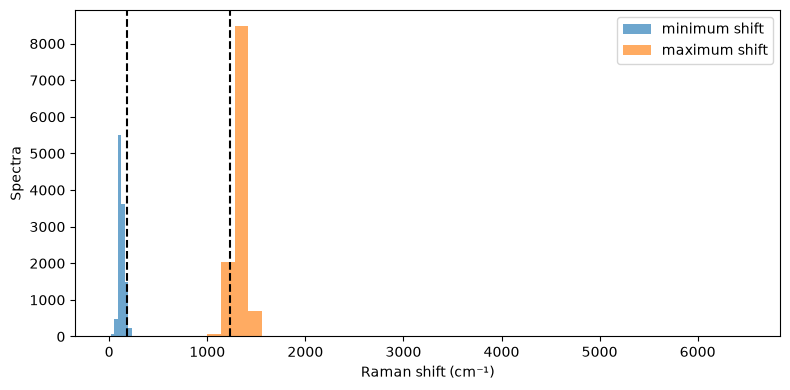

Selected interval: 180.71–1236.15 cm⁻¹
Grid: 512 points; spacing 2.065 cm⁻¹


,parsed,complete_coverage
dataset_subset,,
excellent_oriented,7659,6938
excellent_unoriented,11415,10299
fair_oriented,25,20
fair_unoriented,2951,2338
poor_unoriented,1639,1324
unrated_oriented,3773,3533
unrated_unoriented,637,567


Spectra with complete coverage: 25019


In [5]:
ok = manifest[manifest["accepted_parse"]].copy()
ok_excellent = ok[ok["dataset_subset"] == "excellent_unoriented"].copy()
if ok_excellent.empty:
    raise RuntimeError("No excellent-unoriented spectra parsed successfully.")
LOWER_LIMIT = float(np.quantile(ok_excellent["min_shift"], COVERAGE_FRACTION))
UPPER_LIMIT = float(np.quantile(ok_excellent["max_shift"], 1 - COVERAGE_FRACTION))
if LOWER_LIMIT >= UPPER_LIMIT:
    raise RuntimeError("No valid common Raman interval was found. Inspect the coverage plot and data files.")
target_grid = np.linspace(LOWER_LIMIT, UPPER_LIMIT, N_GRID_POINTS, dtype=np.float32)

coverage_ok = (ok["min_shift"] <= LOWER_LIMIT) & (ok["max_shift"] >= UPPER_LIMIT)
coverage_ids = set(ok.loc[coverage_ok, "spectrum_id"])
manifest["accepted_coverage"] = manifest["spectrum_id"].isin(coverage_ids)
mask = manifest["accepted_parse"] & ~manifest["accepted_coverage"]
manifest.loc[mask, "rejection_reason"] = "insufficient common-interval coverage"

plt.figure(figsize=(8, 4))
plt.hist(ok_excellent["min_shift"], bins=40, alpha=0.65, label="minimum shift")
plt.hist(ok_excellent["max_shift"], bins=40, alpha=0.65, label="maximum shift")
plt.axvline(LOWER_LIMIT, color="black", linestyle="--")
plt.axvline(UPPER_LIMIT, color="black", linestyle="--")
plt.xlabel("Raman shift (cm⁻¹)"); plt.ylabel("Spectra"); plt.legend(); plt.tight_layout(); plt.show()

print(f"Selected interval: {LOWER_LIMIT:.2f}–{UPPER_LIMIT:.2f} cm⁻¹")
print(f"Grid: {N_GRID_POINTS} points; spacing {target_grid[1]-target_grid[0]:.3f} cm⁻¹")
display(manifest[manifest["accepted_parse"]].groupby("dataset_subset")["accepted_coverage"].agg(parsed="size", complete_coverage="sum"))
print("Spectra with complete coverage:", len(coverage_ids))


## Armonización, normalización y filtrado de clases

Cada espectro aceptado se interpola linealmente solo dentro de su rango medido y se normaliza por su intensidad absoluta máxima. Después se aplican los requisitos mínimos de observaciones y, cuando corresponde, de fuentes independientes. Las clases excluidas no disponen de evidencia suficiente para formar particiones evaluables de manera fiable.


In [6]:
X_list, labels, metadata_rows = [], [], []
for row in manifest[manifest["accepted_coverage"]].itertuples():
    shift, intensity = parsed[row.spectrum_id]
    interpolated = np.interp(target_grid, shift, intensity).astype(np.float32)
    scale = float(np.max(np.abs(interpolated)))
    if not np.isfinite(scale) or scale <= 1e-12:
        manifest.loc[manifest["spectrum_id"] == row.spectrum_id, "accepted_coverage"] = False
        manifest.loc[manifest["spectrum_id"] == row.spectrum_id, "rejection_reason"] = "invalid normalization divisor"
        continue
    normalized = (interpolated / scale).astype(np.float32)
    if not np.isfinite(normalized).all():
        raise AssertionError(f"Non-finite normalized values in {row.filepath}")
    X_list.append(normalized); labels.append(row.label)
    metadata_rows.append({
        "spectrum_id": row.spectrum_id, "filepath": row.filepath, "filename": row.filename,
        "dataset_subset": row.dataset_subset, "label": row.label, "source_id": row.source_id, "source_id_status": row.source_id_status,
    })

X_all = np.asarray(X_list, dtype=np.float32)
metadata_all = pd.DataFrame(metadata_rows)
missing_source = metadata_all["source_id"].isna()
n_unresolved = int(missing_source.sum())
if n_unresolved:
    unresolved = metadata_all.loc[missing_source, [
        "spectrum_id", "filepath", "filename", "dataset_subset", "label", "source_id_status"
    ]].copy()
    unresolved.to_csv(RESULTS_DIR / "excluded_unresolved_source_ids.csv", index=False)
    print(f"Quarantining {n_unresolved} usable spectra without a uniquely resolved source ID.")
    display(unresolved.head(30))

if REQUIRE_RELIABLE_SOURCE_IDS:
    resolved_mask = (~missing_source).to_numpy()
    X_all = X_all[resolved_mask]
    metadata_all = metadata_all.loc[~missing_source].reset_index(drop=True)

if len(metadata_all) == 0:
    raise RuntimeError(
        "No spectra with reliable source IDs remain. Review source_id_audit.csv and "
        "excluded_unresolved_source_ids.csv; group-aware evaluation cannot run."
    )

source_label_counts = metadata_all.groupby("source_id")["label"].nunique()
colliding_sources = source_label_counts[source_label_counts > 1]
n_conflicting_sources = int(len(colliding_sources))
n_conflicting_spectra = 0
if n_conflicting_sources:
    conflict_mask = metadata_all["source_id"].isin(colliding_sources.index)
    collision_rows = metadata_all.loc[conflict_mask].copy()
    n_conflicting_spectra = int(conflict_mask.sum())
    collision_rows.to_csv(RESULTS_DIR / "source_label_conflicts.csv", index=False)
    conflict_summary = (collision_rows.groupby("source_id")
                        .agg(n_labels=("label", "nunique"),
                             labels=("label", lambda s: " | ".join(sorted(set(s)))),
                             n_spectra=("spectrum_id", "size"))
                        .reset_index().sort_values(["n_labels", "n_spectra"], ascending=False))
    conflict_summary.to_csv(RESULTS_DIR / "source_label_conflict_summary.csv", index=False)
    print(f"Quarantining {n_conflicting_spectra} spectra from {n_conflicting_sources} source IDs that map to multiple labels.")
    display(conflict_summary.head(30))
    clean_mask = (~conflict_mask).to_numpy()
    X_all = X_all[clean_mask]
    metadata_all = metadata_all.loc[~conflict_mask].reset_index(drop=True)

if len(metadata_all) == 0:
    raise RuntimeError(
        "No unambiguous source groups remain after quarantining cross-label conflicts. "
        "Review source_label_conflict_summary.csv; group-aware evaluation cannot run."
    )

excellent_clean = metadata_all[metadata_all["dataset_subset"] == "excellent_unoriented"]
class_spectrum_counts = excellent_clean["label"].value_counts()
class_source_counts = excellent_clean.groupby("label")["source_id"].nunique()
class_audit = pd.concat([
    class_spectrum_counts.rename("usable_spectra"),
    class_source_counts.rename("distinct_sources"),
], axis=1).fillna(0)
class_audit["retained"] = (
    (class_audit["usable_spectra"] >= MIN_CLASS_COUNT) &
    (class_audit["distinct_sources"] >= MIN_SOURCE_GROUPS)
)
class_audit["exclusion_reason"] = np.where(
    class_audit["usable_spectra"] < MIN_CLASS_COUNT, "too_few_spectra",
    np.where(class_audit["distinct_sources"] < MIN_SOURCE_GROUPS, "fewer_than_3_sources", "")
)
class_audit.to_csv(RESULTS_DIR / "class_source_audit.csv")

valid_classes = set(class_audit.index[class_audit["retained"]])
if not valid_classes:
    raise RuntimeError(
        "No mineral class has at least three unambiguous source groups after auditing. "
        "Review class_source_audit.csv; a group-aware train/validation/test experiment is not supported by these identifiers."
    )
keep = metadata_all["label"].isin(valid_classes).to_numpy()
X = X_all[keep]
metadata = metadata_all.loc[keep].reset_index(drop=True)

encoder = LabelEncoder()
y = encoder.fit_transform(metadata["label"]).astype(np.int32)
class_names = encoder.classes_
n_classes = len(class_names)
X_cnn = X[..., np.newaxis].astype(np.float32)

assert len(X_cnn) == len(y) == len(metadata)
assert X_cnn.shape == (len(X), N_GRID_POINTS, 1)
assert X_cnn.dtype == np.float32 and np.isfinite(X_cnn).all()
assert metadata["source_id"].notna().all()
assert metadata.groupby("source_id")["label"].nunique().max() == 1
assert metadata[metadata["dataset_subset"] == "excellent_unoriented"].groupby("label")["source_id"].nunique().min() >= MIN_SOURCE_GROUPS

manifest.to_csv(RESULTS_DIR / "final_manifest.csv", index=False)
pd.DataFrame({"class_index": np.arange(n_classes), "label": class_names}).to_csv(
    RESULTS_DIR / "label_mapping.csv", index=False
)

display(metadata.groupby("dataset_subset").agg(spectra=("spectrum_id", "size"), sources=("source_id", "nunique")))
print("Usable spectra after source-aware class filtering:", len(X))
print("Usable spectra excluded for unresolved source ID:", n_unresolved)
print("Usable spectra excluded for cross-label source conflict:", n_conflicting_spectra)
print("Conflicting source IDs quarantined:", n_conflicting_sources)
print("Retained classes:", n_classes)
print("Distinct retained sources:", metadata["source_id"].nunique())
print("Excluded classes:", int((~class_audit["retained"]).sum()))
print("✓ Harmonized data and reliable source groups established")



[SOLO PANTALLA] raman_group_aware_all_7_zips_verified/results/excluded_unresolved_source_ids.csv | dimensiones: (1678, 6)


,spectrum_id,filepath,filename,dataset_subset,label,source_id_status
56,S000062,excellent_unoriented.zip::Adelite__R060687__Ra...,Adelite__R060687__Raman__532______Raman_Data_P...,excellent_unoriented,Adelite,filename_header_conflict
57,S000063,excellent_unoriented.zip::Adelite__R060687__Ra...,Adelite__R060687__Raman__532______Raman_Data_R...,excellent_unoriented,Adelite,filename_header_conflict
58,S000065,excellent_unoriented.zip::Adelite__R060687__Ra...,Adelite__R060687__Raman__785______Raman_Data_R...,excellent_unoriented,Adelite,filename_header_conflict
94,S000108,excellent_unoriented.zip::Aeschynite-(Y)__R080...,Aeschynite-(Y)__R080045__Raman__532______Raman...,excellent_unoriented,Aeschynite-(Y),filename_header_conflict
95,S000109,excellent_unoriented.zip::Aeschynite-(Y)__R080...,Aeschynite-(Y)__R080045__Raman__532______Raman...,excellent_unoriented,Aeschynite-(Y),filename_header_conflict
104,S000119,excellent_unoriented.zip::Afwillite__R070296__...,Afwillite__R070296__Raman__532______Raman_Data...,excellent_unoriented,Afwillite,filename_header_conflict
105,S000120,excellent_unoriented.zip::Afwillite__R070296__...,Afwillite__R070296__Raman__532______Raman_Data...,excellent_unoriented,Afwillite,filename_header_conflict
106,S000123,excellent_unoriented.zip::Afwillite__R080022__...,Afwillite__R080022__Raman__532______Raman_Data...,excellent_unoriented,Afwillite,filename_header_conflict
107,S000124,excellent_unoriented.zip::Afwillite__R080022__...,Afwillite__R080022__Raman__532______Raman_Data...,excellent_unoriented,Afwillite,filename_header_conflict
108,S000125,excellent_unoriented.zip::Afwillite__R080022__...,Afwillite__R080022__Raman__780______Raman_Data...,excellent_unoriented,Afwillite,filename_header_conflict


Quarantining 1678 usable spectra without a uniquely resolved source ID.


,spectrum_id,filepath,filename,dataset_subset,label,source_id_status
56,S000062,excellent_unoriented.zip::Adelite__R060687__Ra...,Adelite__R060687__Raman__532______Raman_Data_P...,excellent_unoriented,Adelite,filename_header_conflict
57,S000063,excellent_unoriented.zip::Adelite__R060687__Ra...,Adelite__R060687__Raman__532______Raman_Data_R...,excellent_unoriented,Adelite,filename_header_conflict
58,S000065,excellent_unoriented.zip::Adelite__R060687__Ra...,Adelite__R060687__Raman__785______Raman_Data_R...,excellent_unoriented,Adelite,filename_header_conflict
94,S000108,excellent_unoriented.zip::Aeschynite-(Y)__R080...,Aeschynite-(Y)__R080045__Raman__532______Raman...,excellent_unoriented,Aeschynite-(Y),filename_header_conflict
95,S000109,excellent_unoriented.zip::Aeschynite-(Y)__R080...,Aeschynite-(Y)__R080045__Raman__532______Raman...,excellent_unoriented,Aeschynite-(Y),filename_header_conflict
104,S000119,excellent_unoriented.zip::Afwillite__R070296__...,Afwillite__R070296__Raman__532______Raman_Data...,excellent_unoriented,Afwillite,filename_header_conflict
105,S000120,excellent_unoriented.zip::Afwillite__R070296__...,Afwillite__R070296__Raman__532______Raman_Data...,excellent_unoriented,Afwillite,filename_header_conflict
106,S000123,excellent_unoriented.zip::Afwillite__R080022__...,Afwillite__R080022__Raman__532______Raman_Data...,excellent_unoriented,Afwillite,filename_header_conflict
107,S000124,excellent_unoriented.zip::Afwillite__R080022__...,Afwillite__R080022__Raman__532______Raman_Data...,excellent_unoriented,Afwillite,filename_header_conflict
108,S000125,excellent_unoriented.zip::Afwillite__R080022__...,Afwillite__R080022__Raman__780______Raman_Data...,excellent_unoriented,Afwillite,filename_header_conflict



[SOLO PANTALLA] raman_group_aware_all_7_zips_verified/results/source_label_conflicts.csv | dimensiones: (27, 7)


...

,spectrum_id,filepath,filename,dataset_subset,label,accepted_parse,rejection_reason,source_id_filename,source_id_header,source_id,source_id_status,n_points,min_shift,max_shift,accepted_coverage
0,S000000,excellent_unoriented.zip::Abellaite__R250095__...,Abellaite__R250095__Raman__532______Raman_Data...,excellent_unoriented,Abellaite,True,None,R250095,R250095,R250095,filename_header_agree,3209,50.00000,1301.270,True
1,S000001,excellent_unoriented.zip::Abellaite__R250095__...,Abellaite__R250095__Raman__532______Raman_Data...,excellent_unoriented,Abellaite,True,None,R250095,R250095,R250095,filename_header_agree,3209,50.00000,1301.270,True
2,S000002,excellent_unoriented.zip::Abelsonite__R070007_...,Abelsonite__R070007__Raman__532______Raman_Dat...,excellent_unoriented,Abelsonite,True,None,R070007,R070007,R070007,filename_header_agree,2312,153.55700,1267.727,True
3,S000003,excellent_unoriented.zip::Abelsonite__R070007_...,Abelsonite__R070007__Raman__532______Raman_Dat...,excellent_unoriented,Abelsonite,True,None,R070007,R070007,R070007,filename_header_agree,2379,153.55700,1300.029,True
4,S000004,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite__R060227__Raman__532______Raman_Data_...,excellent_unoriented,Abhurite,True,None,R060227,R060227,R060227,filename_header_agree,2367,163.43140,1304.119,True
5,S000005,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite__R060227__Raman__532______Raman_Data_...,excellent_unoriented,Abhurite,True,None,R060227,R060227,R060227,filename_header_agree,2515,92.07813,1304.119,True
6,S000006,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite__R060227__Raman__780______Raman_Data_...,excellent_unoriented,Abhurite,True,None,R060227,R060227,R060227,filename_header_agree,2476,91.82715,1285.066,True
7,S000007,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite__R060227__Raman__780______Raman_Data_...,excellent_unoriented,Abhurite,True,None,R060227,R060227,R060227,filename_header_agree,2476,91.82715,1285.066,True
8,S000008,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__514______Raman_Dat...,excellent_unoriented,Actinolite,True,None,R040063,R040063,R040063,filename_header_agree,1077,139.24300,1513.235,True
9,S000009,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__514______Raman_Dat...,excellent_unoriented,Actinolite,True,None,R040063,R040063,R040063,filename_header_agree,1077,139.24300,1513.235,True



[SOLO PANTALLA] raman_group_aware_all_7_zips_verified/results/label_mapping.csv | dimensiones: (208, 2)


,class_index,label
0,0,Actinolite
1,1,Adamite
2,2,Aegirine
3,3,Agardite-(Y)
4,4,Albite
5,5,Alluaudite
6,6,Almandine
7,7,Alum-(K)
8,8,Andalusite
9,9,Andradite


,spectra,sources
dataset_subset,,
excellent_oriented,4553,290
excellent_unoriented,3441,912
fair_oriented,10,2
fair_unoriented,337,135
poor_unoriented,190,93
unrated_oriented,2418,326
unrated_unoriented,30,19


Usable spectra after source-aware class filtering: 10979
Usable spectra excluded for unresolved source ID: 1678
Usable spectra excluded for cross-label source conflict: 27
Conflicting source IDs quarantined: 2
Retained classes: 208
Distinct retained sources: 964
Excluded classes: 1543
✓ Harmonized data and reliable source groups established


## Armonización, normalización y filtrado de clases

Cada espectro aceptado se interpola linealmente solo dentro de su rango medido y se normaliza por su intensidad absoluta máxima. Después se aplican los requisitos mínimos de observaciones y, cuando corresponde, de fuentes independientes. Las clases excluidas no disponen de evidencia suficiente para formar particiones evaluables de manera fiable.


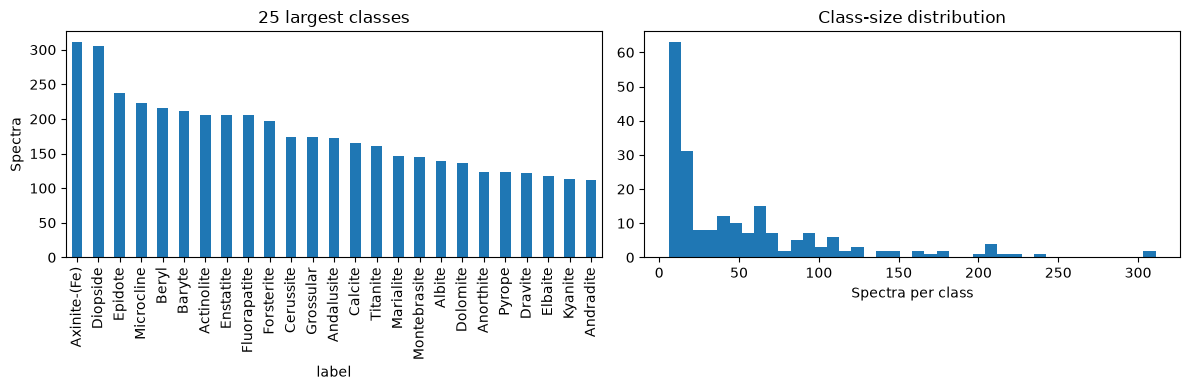

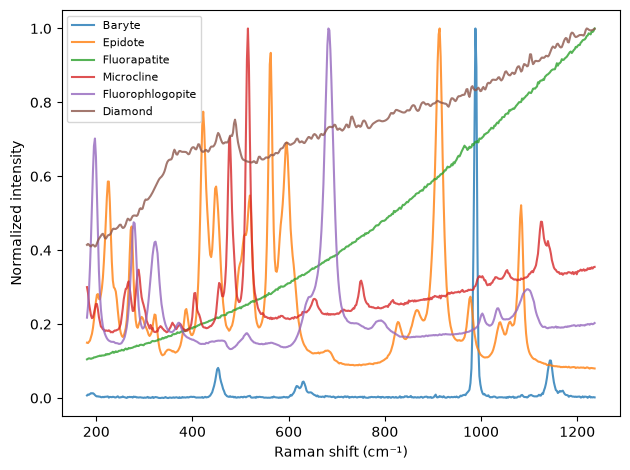

In [7]:
counts = metadata["label"].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts.head(25).plot.bar(ax=axes[0]); axes[0].set_title("25 largest classes"); axes[0].set_ylabel("Spectra")
axes[1].hist(counts.values, bins=40); axes[1].set_title("Class-size distribution"); axes[1].set_xlabel("Spectra per class")
plt.tight_layout(); plt.show()

rng = np.random.default_rng(SEED)
for idx in rng.choice(len(X), size=min(6, len(X)), replace=False):
    plt.plot(target_grid, X[idx], alpha=0.8, label=metadata.loc[idx, "label"])
plt.xlabel("Raman shift (cm⁻¹)"); plt.ylabel("Normalized intensity")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()


## Construcción de entrenamiento, validación y prueba

Entrenamiento se utiliza para ajustar los pesos; validación controla la parada temprana y la selección del checkpoint; test permanece intacto hasta la evaluación final. En las versiones `group-aware`, todas las mediciones asociadas a una misma fuente RRUFF permanecen en una sola partición. Así se evita que réplicas o mediciones estrechamente relacionadas aparezcan a ambos lados de la evaluación.


In [8]:
def classwise_group_split(metadata_subset, seed=42):
    rng = np.random.default_rng(seed)
    train_idx, val_idx, test_idx = [], [], []
    allocation_rows = []
    for label in sorted(metadata_subset["label"].unique()):
        class_rows = metadata_subset.index[metadata_subset["label"] == label].to_numpy()
        sources = metadata_subset.loc[class_rows, "source_id"].drop_duplicates().to_numpy(dtype=object)
        if len(sources) < 3:
            raise AssertionError(f"{label} has fewer than three excellent source groups")
        rng.shuffle(sources)
        test_source, val_source = sources[0], sources[1]
        for source_id in sources:
            idx = metadata_subset.index[
                (metadata_subset["label"] == label) & (metadata_subset["source_id"] == source_id)
            ].to_list()
            partition = "test" if source_id == test_source else "validation" if source_id == val_source else "train"
            {"train": train_idx, "validation": val_idx, "test": test_idx}[partition].extend(idx)
            allocation_rows.append({
                "label": label, "source_id": source_id, "partition": partition,
                "n_spectra": len(idx), "dataset_subset": "excellent_unoriented",
            })
    arrays = tuple(np.asarray(sorted(v), dtype=np.int64) for v in (train_idx, val_idx, test_idx))
    return arrays, pd.DataFrame(allocation_rows)

excellent_metadata = metadata[metadata["dataset_subset"] == "excellent_unoriented"]
(excellent_train_idx, val_idx, test_idx), source_allocation = classwise_group_split(excellent_metadata, SEED)

heldout_sources = set(metadata.loc[val_idx, "source_id"]) | set(metadata.loc[test_idx, "source_id"])
auxiliary_mask = metadata["dataset_subset"] != "excellent_unoriented"
auxiliary_leakage_mask = auxiliary_mask & metadata["source_id"].isin(heldout_sources)
auxiliary_eligible_mask = auxiliary_mask & ~metadata["source_id"].isin(heldout_sources)
auxiliary_train_idx = metadata.index[auxiliary_eligible_mask].to_numpy(dtype=np.int64)
train_idx = np.asarray(sorted(np.concatenate([excellent_train_idx, auxiliary_train_idx])), dtype=np.int64)

excluded_auxiliary_leakage = metadata.loc[auxiliary_leakage_mask].copy()
excluded_auxiliary_leakage.to_csv(
    RESULTS_DIR / "auxiliary_spectra_excluded_heldout_source_leakage.csv", index=False
)

assert set(train_idx).isdisjoint(val_idx)
assert set(train_idx).isdisjoint(test_idx)
assert set(val_idx).isdisjoint(test_idx)
assert set(np.unique(y[train_idx])) == set(np.unique(y[val_idx])) == set(np.unique(y[test_idx]))
assert (metadata.loc[val_idx, "dataset_subset"] == "excellent_unoriented").all()
assert (metadata.loc[test_idx, "dataset_subset"] == "excellent_unoriented").all()

partition_sources = {
    "train": set(metadata.loc[train_idx, "source_id"]),
    "validation": set(metadata.loc[val_idx, "source_id"]),
    "test": set(metadata.loc[test_idx, "source_id"]),
}
assert partition_sources["train"].isdisjoint(partition_sources["validation"])
assert partition_sources["train"].isdisjoint(partition_sources["test"])
assert partition_sources["validation"].isdisjoint(partition_sources["test"])

X_train, y_train = X_cnn[train_idx], y[train_idx]
X_val, y_val = X_cnn[val_idx], y[val_idx]
X_test, y_test = X_cnn[test_idx], y[test_idx]

split_name = np.full(len(y), "excluded_not_used", dtype=object)
split_name[train_idx] = "train"
split_name[val_idx] = "validation"
split_name[test_idx] = "test"
split_name[metadata.index[auxiliary_leakage_mask]] = "excluded_auxiliary_heldout_source_leakage"
split_manifest = metadata.copy()
split_manifest["class_index"] = y
split_manifest["partition"] = split_name
split_manifest.to_csv(RESULTS_DIR / "group_aware_split_manifest.csv", index=False)

auxiliary_allocation = (metadata.loc[auxiliary_train_idx]
                        .groupby(["label", "source_id", "dataset_subset"], as_index=False)
                        .agg(n_spectra=("spectrum_id", "size")))
auxiliary_allocation["partition"] = "train"
source_allocation = pd.concat([source_allocation, auxiliary_allocation], ignore_index=True)
source_allocation.to_csv(RESULTS_DIR / "source_group_allocation.csv", index=False)
np.save(RESULTS_DIR / "train_indices.npy", train_idx)
np.save(RESULTS_DIR / "validation_indices.npy", val_idx)
np.save(RESULTS_DIR / "test_indices.npy", test_idx)

active_split = split_manifest[split_manifest["partition"].isin(["train", "validation", "test"])]
display(active_split.groupby(["partition", "dataset_subset"])
        .agg(sources=("source_id", "nunique"), spectra=("spectrum_id", "size")))

auxiliary_report = pd.concat([
    metadata.loc[auxiliary_train_idx].groupby("dataset_subset").size().rename("training_spectra_added"),
    excluded_auxiliary_leakage.groupby("dataset_subset").size().rename("heldout_overlap_spectra_excluded"),
], axis=1).fillna(0).astype(int).reset_index()
auxiliary_report.to_csv(RESULTS_DIR / "auxiliary_training_admission_by_archive.csv", index=False)
display(auxiliary_report)

# One auditable row per required ZIP across every major admission stage.
archive_stage_report = archive_inventory[["dataset_subset", "zip_filename", "role"]].copy()
archive_stage_report = archive_stage_report.merge(parse_by_archive, on="dataset_subset", how="left")
coverage_report = (manifest[manifest["accepted_parse"]]
                   .groupby("dataset_subset", as_index=False)
                   .agg(coverage_accepted_spectra=("accepted_coverage", "sum")))
retained_report = (metadata.groupby("dataset_subset", as_index=False)
                   .agg(source_audited_retained_spectra=("spectrum_id", "size"),
                        source_audited_retained_sources=("source_id", "nunique")))
training_report = (active_split[active_split["partition"] == "train"]
                   .groupby("dataset_subset", as_index=False)
                   .agg(training_spectra_admitted=("spectrum_id", "size"),
                        training_sources_admitted=("source_id", "nunique")))
heldout_report = (excluded_auxiliary_leakage.groupby("dataset_subset", as_index=False)
                  .agg(heldout_overlap_spectra_excluded=("spectrum_id", "size")))
for stage in (coverage_report, retained_report, training_report, heldout_report):
    archive_stage_report = archive_stage_report.merge(stage, on="dataset_subset", how="left")
count_columns = [c for c in archive_stage_report.columns if c not in {"dataset_subset", "zip_filename", "role"}]
archive_stage_report[count_columns] = archive_stage_report[count_columns].fillna(0).astype(int)
archive_stage_report["considered"] = True
assert len(archive_stage_report) == 7
assert set(archive_stage_report["zip_filename"]) == set(REQUIRED_ZIP_FILENAMES)
assert archive_stage_report["parsed_spectra"].gt(0).all()
archive_stage_report.to_csv(RESULTS_DIR / "ALL_7_ZIPS_STAGE_REPORT.csv", index=False)
display(archive_stage_report)

zero_training = archive_stage_report.loc[
    archive_stage_report["training_spectra_admitted"] == 0, "zip_filename"
].tolist()
if zero_training:
    print("NOTICE: These ZIPs were fully considered but added zero training spectra after scientific exclusions:")
    print("  " + ", ".join(zero_training))
    print("Inspect ALL_7_ZIPS_STAGE_REPORT.csv and the exclusion audit files; no archive was silently skipped.")
else:
    print("✓ Every one of the seven ZIPs contributed at least one admitted training spectrum")

print(f"Excellent training spectra: {len(excellent_train_idx)}")
print(f"Eligible auxiliary training spectra added: {len(auxiliary_train_idx)}")
print(f"Auxiliary spectra excluded due to held-out source leakage: {len(excluded_auxiliary_leakage)}")
print(f"Total training: {len(train_idx)} | Validation: {len(val_idx)} | Test: {len(test_idx)}")
print("✓ Excellent evaluation split preserved; all eligible auxiliary archives added only to training")



[SOLO PANTALLA] raman_group_aware_all_7_zips_verified/results/auxiliary_spectra_excluded_heldout_source_leakage.csv | dimensiones: (3005, 7)


,spectrum_id,filepath,filename,dataset_subset,label,source_id,source_id_status
3441,S011429,poor_unoriented.zip::Agardite-(Y)__R070649__Ra...,Agardite-(Y)__R070649__Raman__780______Raman_D...,poor_unoriented,Agardite-(Y),R070649,filename_header_agree
3442,S011430,poor_unoriented.zip::Agardite-(Y)__R070649__Ra...,Agardite-(Y)__R070649__Raman__780______Raman_D...,poor_unoriented,Agardite-(Y),R070649,filename_header_agree
3454,S011640,poor_unoriented.zip::Brochantite__R060133__Ram...,Brochantite__R060133__Raman__780______Raman_Da...,poor_unoriented,Brochantite,R060133,filename_header_agree
3455,S011641,poor_unoriented.zip::Brochantite__R060133__Ram...,Brochantite__R060133__Raman__780______Raman_Da...,poor_unoriented,Brochantite,R060133,filename_header_agree
3456,S011642,poor_unoriented.zip::Brochantite__R100199__Ram...,Brochantite__R100199__Raman__780______Raman_Da...,poor_unoriented,Brochantite,R100199,filename_header_agree
3457,S011643,poor_unoriented.zip::Brochantite__R100199__Ram...,Brochantite__R100199__Raman__780______Raman_Da...,poor_unoriented,Brochantite,R100199,filename_header_agree
3463,S011734,poor_unoriented.zip::Chalcopyrite__R050222__Ra...,Chalcopyrite__R050222__Raman__780______Raman_D...,poor_unoriented,Chalcopyrite,R050222,filename_header_agree
3464,S011735,poor_unoriented.zip::Chalcopyrite__R050559__Ra...,Chalcopyrite__R050559__Raman__780______Raman_D...,poor_unoriented,Chalcopyrite,R050559,filename_header_agree
3465,S011736,poor_unoriented.zip::Chalcopyrite__R050559__Ra...,Chalcopyrite__R050559__Raman__780______Raman_D...,poor_unoriented,Chalcopyrite,R050559,filename_header_agree
3470,S011779,poor_unoriented.zip::Clinoatacamite__R141083__...,Clinoatacamite__R141083__Raman__780______Raman...,poor_unoriented,Clinoatacamite,R141083,filename_header_agree



[SOLO PANTALLA] raman_group_aware_all_7_zips_verified/results/group_aware_split_manifest.csv | dimensiones: (10979, 9)


,spectrum_id,filepath,filename,dataset_subset,label,source_id,source_id_status,class_index,partition
0,S000008,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__514______Raman_Dat...,excellent_unoriented,Actinolite,R040063,filename_header_agree,0,train
1,S000009,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__514______Raman_Dat...,excellent_unoriented,Actinolite,R040063,filename_header_agree,0,train
2,S000010,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__532______Raman_Dat...,excellent_unoriented,Actinolite,R040063,filename_header_agree,0,train
3,S000011,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__532______Raman_Dat...,excellent_unoriented,Actinolite,R040063,filename_header_agree,0,train
4,S000012,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__785______Raman_Dat...,excellent_unoriented,Actinolite,R040063,filename_header_agree,0,train
5,S000013,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__785______Raman_Dat...,excellent_unoriented,Actinolite,R040063,filename_header_agree,0,train
6,S000014,excellent_unoriented.zip::Actinolite__R040064_...,Actinolite__R040064__Raman__514______Raman_Dat...,excellent_unoriented,Actinolite,R040064,filename_header_agree,0,train
7,S000015,excellent_unoriented.zip::Actinolite__R040064_...,Actinolite__R040064__Raman__514______Raman_Dat...,excellent_unoriented,Actinolite,R040064,filename_header_agree,0,train
8,S000016,excellent_unoriented.zip::Actinolite__R040064_...,Actinolite__R040064__Raman__532______Raman_Dat...,excellent_unoriented,Actinolite,R040064,filename_header_agree,0,train
9,S000017,excellent_unoriented.zip::Actinolite__R040064_...,Actinolite__R040064__Raman__532______Raman_Dat...,excellent_unoriented,Actinolite,R040064,filename_header_agree,0,train



[SOLO PANTALLA] raman_group_aware_all_7_zips_verified/results/source_group_allocation.csv | dimensiones: (1442, 5)


...

,dataset_subset,training_spectra_added,heldout_overlap_spectra_excluded
0,excellent_oriented,2662,1891
1,fair_oriented,2,8
2,fair_unoriented,233,104
3,poor_unoriented,115,75
4,unrated_oriented,1506,912
5,unrated_unoriented,15,15



[SOLO PANTALLA] raman_group_aware_all_7_zips_verified/results/ALL_7_ZIPS_STAGE_REPORT.csv | dimensiones: (7, 12)


,dataset_subset,zip_filename,role,unique_text_files,parsed_spectra,coverage_accepted_spectra,source_audited_retained_spectra,source_audited_retained_sources,training_spectra_admitted,training_sources_admitted,heldout_overlap_spectra_excluded,considered
0,excellent_unoriented,excellent_unoriented.zip,benchmark_train_validation_test,11415,11415,10299,3441,912,1908,496,0,True
1,poor_unoriented,poor_unoriented.zip,auxiliary_training_only,1639,1639,1324,190,93,115,57,75,True
2,unrated_oriented,unrated_oriented.zip,auxiliary_training_only,3773,3773,3533,2418,326,1506,203,912,True
3,unrated_unoriented,unrated_unoriented.zip,auxiliary_training_only,637,637,567,30,19,15,8,15,True
4,excellent_oriented,excellent_oriented.zip,auxiliary_training_only,7659,7659,6938,4553,290,2662,175,1891,True
5,fair_oriented,fair_oriented.zip,auxiliary_training_only,25,25,20,10,2,2,1,8,True
6,fair_unoriented,fair_unoriented.zip,auxiliary_training_only,2951,2951,2338,337,135,233,86,104,True


,dataset_subset,zip_filename,role,unique_text_files,parsed_spectra,coverage_accepted_spectra,source_audited_retained_spectra,source_audited_retained_sources,training_spectra_admitted,training_sources_admitted,heldout_overlap_spectra_excluded,considered
0,excellent_unoriented,excellent_unoriented.zip,benchmark_train_validation_test,11415,11415,10299,3441,912,1908,496,0,True
1,poor_unoriented,poor_unoriented.zip,auxiliary_training_only,1639,1639,1324,190,93,115,57,75,True
2,unrated_oriented,unrated_oriented.zip,auxiliary_training_only,3773,3773,3533,2418,326,1506,203,912,True
3,unrated_unoriented,unrated_unoriented.zip,auxiliary_training_only,637,637,567,30,19,15,8,15,True
4,excellent_oriented,excellent_oriented.zip,auxiliary_training_only,7659,7659,6938,4553,290,2662,175,1891,True
5,fair_oriented,fair_oriented.zip,auxiliary_training_only,25,25,20,10,2,2,1,8,True
6,fair_unoriented,fair_unoriented.zip,auxiliary_training_only,2951,2951,2338,337,135,233,86,104,True


✓ Every one of the seven ZIPs contributed at least one admitted training spectrum
Excellent training spectra: 1908
Eligible auxiliary training spectra added: 4533
Auxiliary spectra excluded due to held-out source leakage: 3005
Total training: 6441 | Validation: 781 | Test: 752
✓ Excellent evaluation split preserved; all eligible auxiliary archives added only to training


## Pesos de clase calculados con entrenamiento

Los pesos compensan parcialmente el desbalance, dando más importancia a clases escasas durante la optimización. Se calculan exclusivamente con las etiquetas originales de entrenamiento. Validación y test no participan en este cálculo, por lo que continúan representando datos no utilizados para ajustar el modelo.


In [9]:
weights = compute_class_weight(class_weight="balanced", classes=np.arange(n_classes), y=y_train)
class_weight_dict = {int(i): float(w) for i, w in enumerate(weights)}
(RESULTS_DIR / "class_weights.json").write_text(json.dumps(class_weight_dict, indent=2))
print("Weight range:", f"{weights.min():.3f}–{weights.max():.3f}")
print("✓ Training-only class weights calculated")


[SOLO PANTALLA] class_weights.json:
{
  "0": 0.24004919499105545,
  "1": 1.105940934065934,
  "2": 0.619326923076923,
  "3": 5.1610576923076925,
  "4": 0.2949175824175824,
  "5": 2.8151223776223775,
  "6": 0.38707932692307695,
  "7": 7.741586538461538,
  "8": 0.27163461538461536,
  "9": 0.36007379248658317,
  "10": 1.0322115384615385,
  "11": 15.483173076923077,
  "12": 0.26242666232073014,
  "13": 0.9676983173076923,
  "14": 7.741586538461538,
  "15": 15.483173076923077,
  "16": 5.1610576923076925,
  "17": 0.5248533246414603,
  "18": 0.14887666420118342,
  "19": 7.741586538461538,
  "20": 7.741586538461538,
  "21": 0.860176282051282,
  "22": 0.5339025198938993,
  "23": 3.0966346153846156,
  "24": 7.741586538461538,
  "25": 10.322115384615385,
  "26": 0.18881918386491559,
  "27": 3.870793269230769,
  "28": 2.211881868131868,
  "29": 1.0322115384615385,
  "30": 1.1910133136094674,
  "31": 7.741586538461538,
  "32": 1.105940934065934,
  "33": 0.2517589118198874,
  "34": 0.967698317307692

## Aumento de datos exclusivo del entrenamiento

El pipeline introduce pequeñas perturbaciones compatibles con variaciones instrumentales, como desplazamientos limitados del eje y ruido moderado. Se aplica al vuelo solamente a los lotes de entrenamiento. Los espectros de validación y prueba permanecen sin modificar para que las métricas correspondan a observaciones reales y comparables.


[SOLO PANTALLA] Figura mostrada; no se guarda raman_group_aware_all_7_zips_verified/results/augmentation_sanity_check.png


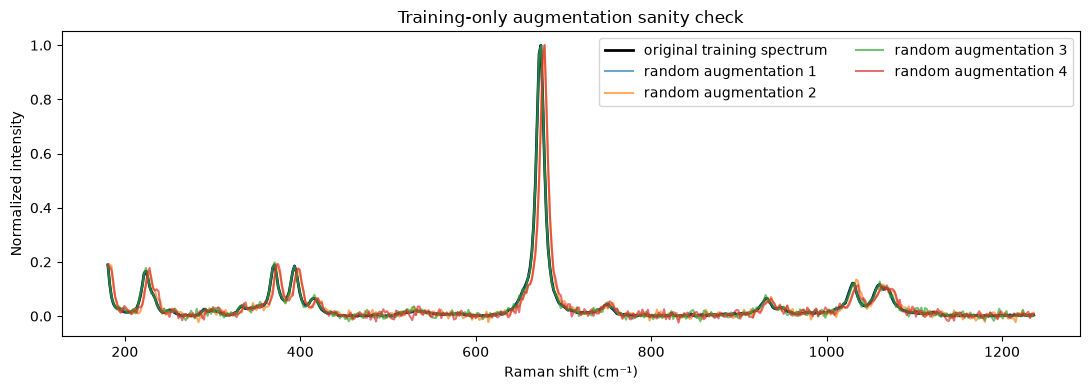

Training dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 512, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
Validation and test arrays unchanged: True
✓ On-the-fly augmentation is connected only to the training pipeline


In [10]:
AUTOTUNE = tf.data.AUTOTUNE

# Immutable reference copies make accidental validation/test modification detectable.
X_val_reference = X_val.copy()
X_test_reference = X_test.copy()

def shift_with_edge_values(spectrum, shift):
    """Shift along the Raman axis without circular wrapping or zero padding."""
    n = tf.shape(spectrum)[0]
    source_positions = tf.clip_by_value(tf.range(n) - shift, 0, n - 1)
    return tf.gather(spectrum, source_positions, axis=0)

def augment_training_spectrum(spectrum, label):
    spectrum = tf.cast(spectrum, tf.float32)

    apply_shift = tf.random.uniform(()) < SHIFT_PROBABILITY
    shift = tf.random.uniform(
        (), minval=-MAX_SHIFT_POINTS, maxval=MAX_SHIFT_POINTS + 1, dtype=tf.int32
    )
    spectrum = tf.cond(
        apply_shift,
        lambda: shift_with_edge_values(spectrum, shift),
        lambda: spectrum,
    )

    apply_noise = tf.random.uniform(()) < NOISE_PROBABILITY
    noise_std = tf.random.uniform((), minval=0.0, maxval=MAX_NOISE_STD)
    spectrum = tf.cond(
        apply_noise,
        lambda: spectrum + tf.random.normal(tf.shape(spectrum), stddev=noise_std),
        lambda: spectrum,
    )

    scale = tf.maximum(tf.reduce_max(tf.abs(spectrum)), tf.constant(1e-7, tf.float32))
    spectrum = spectrum / scale
    spectrum = tf.ensure_shape(spectrum, (N_GRID_POINTS, 1))
    return spectrum, label

train_dataset = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .shuffle(len(X_train), seed=SEED, reshuffle_each_iteration=True)
    .map(augment_training_spectrum, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

assert np.array_equal(X_val, X_val_reference)
assert np.array_equal(X_test, X_test_reference)

# Visual sanity check: these examples are for inspection only and do not alter stored arrays.
example_index = 0
example_batch = next(iter(
    tf.data.Dataset.from_tensors((X_train[example_index], y_train[example_index]))
    .repeat(4).map(augment_training_spectrum).batch(4)
))[0].numpy()

plt.figure(figsize=(11, 4))
plt.plot(target_grid, X_train[example_index, :, 0], color="black", linewidth=2, label="original training spectrum")
for i, augmented in enumerate(example_batch):
    plt.plot(target_grid, augmented[:, 0], alpha=0.65, label=f"random augmentation {i + 1}")
plt.xlabel("Raman shift (cm⁻¹)")
plt.ylabel("Normalized intensity")
plt.title("Training-only augmentation sanity check")
plt.legend(ncol=2)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "augmentation_sanity_check.png", dpi=160)
plt.show()

print("Training dataset:", train_dataset)
print("Validation and test arrays unchanged:",
      np.array_equal(X_val, X_val_reference) and np.array_equal(X_test, X_test_reference))
print("✓ On-the-fly augmentation is connected only to the training pipeline")


## Arquitectura de la CNN 1D

La entrada es el espectro normalizado completo. Las convoluciones aprenden patrones locales asociados a picos y vecindades espectrales; el pooling reduce la resolución y el coste; las capas finales integran la información y la salida softmax asigna una probabilidad a cada clase mineral. Esta etapa conserva la arquitectura de referencia para que los cambios de rendimiento puedan atribuirse principalmente al protocolo de datos.


In [11]:
def build_model(input_shape, n_classes):
    inputs = tf.keras.Input(shape=input_shape, name="spectrum")
    x = inputs
    for filters, kernel in [(32, 11), (64, 7), (128, 5)]:
        x = tf.keras.layers.Conv1D(filters, kernel, padding="same", use_bias=False, kernel_initializer="he_normal")(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.ReLU()(x)
        x = tf.keras.layers.MaxPooling1D(2)(x)
    x = tf.keras.layers.Conv1D(256, 3, padding="same", activation="relu", kernel_initializer="he_normal")(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(256, activation="relu", kernel_initializer="he_normal")(x)
    x = tf.keras.layers.Dropout(0.4)(x)
    outputs = tf.keras.layers.Dense(n_classes, activation="softmax", name="class_probabilities")(x)
    return tf.keras.Model(inputs, outputs, name="basic_raman_cnn")

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)
model = build_model((N_GRID_POINTS, 1), n_classes)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE, clipnorm=1.0),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=min(5, n_classes), name="top_5_accuracy"),
    ],
)
assert model.output_shape[-1] == n_classes
model.summary()

sample_output = model(X_train[:2], training=False).numpy()
assert sample_output.shape == (2, n_classes)
assert np.allclose(sample_output.sum(axis=1), 1.0, atol=1e-5)
print("✓ Model and two-spectrum forward pass verified")


Model: "basic_raman_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ spectrum (InputLayer)           │ (None, 512, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 512, 32)        │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 512, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 256, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 256, 64)        │        14,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 256, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 128, 128)       │        40,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 64, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_probabilities (Dense)     │ (None, 208)            │        53,456 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 274,352 (1.05 MB)

 Trainable params: 273,904 (1.04 MB)

 Non-trainable params: 448 (1.75 KB)

✓ Model and two-spectrum forward pass verified


## Entrenamiento del modelo

El modelo se ajusta únicamente con entrenamiento. La pérdida de validación determina la reducción de la tasa de aprendizaje, la parada temprana y la restauración del mejor checkpoint. El conjunto de prueba no se entrega a `fit` y no interviene en ninguna decisión de entrenamiento.


In [12]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=EARLY_STOPPING_PATIENCE,
        restore_best_weights=True, mode="min", verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=LR_PATIENCE,
        min_lr=1e-6, mode="min", verbose=1,
    ),
]

start = time.time()
history = model.fit(
    train_dataset,
    validation_data=(X_val, y_val),
    epochs=MAX_EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1,
)
training_minutes = (time.time() - start) / 60
print(f"✓ Training completed in {training_minutes:.1f} minutes")


Epoch 1/150


/opt/anaconda3/envs/raman-cnn/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


201/202 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.0187 - loss: 5.4410 - top_5_accuracy: 0.0763

E0000 00:00:1786582242.811417  480774 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


202/202 ━━━━━━━━━━━━━━━━━━━━ 20s 70ms/step - accuracy: 0.0186 - loss: 5.4401 - top_5_accuracy: 0.0764 - val_accuracy: 0.0077 - val_loss: 5.3278 - val_top_5_accuracy: 0.0359 - learning_rate: 0.0010
Epoch 2/150
202/202 ━━━━━━━━━━━━━━━━━━━━ 14s 68ms/step - accuracy: 0.0360 - loss: 5.3060 - top_5_accuracy: 0.1295 - val_accuracy: 0.0077 - val_loss: 5.2947 - val_top_5_accuracy: 0.0410 - learning_rate: 0.0010
Epoch 3/150
202/202 ━━━━━━━━━━━━━━━━━━━━ 14s 70ms/step - accuracy: 0.0584 - loss: 5.1601 - top_5_accuracy: 0.1773 - val_accuracy: 0.0192 - val_loss: 5.1004 - val_top_5_accuracy: 0.0755 - learning_rate: 0.0010
Epoch 4/150
202/202 ━━━━━━━━━━━━━━━━━━━━ 21s 74ms/step - accuracy: 0.0621 - loss: 4.9938 - top_5_accuracy: 0.2068 - val_accuracy: 0.0346 - val_loss: 4.9624 - val_top_5_accuracy: 0.1076 - learning_rate: 0.0010
Epoch 5/150
202/202 ━━━━━━━━━━━━━━━━━━━━ 14s 72ms/step - accuracy: 0.0739 - loss: 4.8029 - top_5_accuracy: 0.2478 - val_accuracy: 0.0487 - val_loss: 4.7428 - val_top_5_accuracy

## Curvas de aprendizaje

Las curvas permiten comparar la evolución en entrenamiento y validación. Si la pérdida de entrenamiento continúa bajando mientras la de validación aumenta, existe evidencia de sobreajuste. También ayudan a comprobar si el entrenamiento terminó por convergencia o por alcanzar el límite de épocas.


[SOLO PANTALLA] Figura mostrada; no se guarda raman_group_aware_all_7_zips_verified/results/learning_curves.png


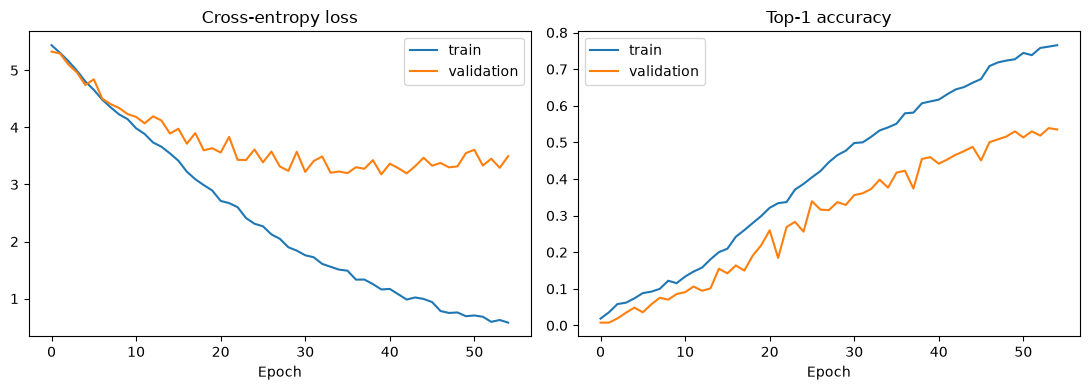

In [13]:
history_df = pd.DataFrame(history.history)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history_df["loss"], label="train"); axes[0].plot(history_df["val_loss"], label="validation")
axes[0].set_title("Cross-entropy loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(history_df["accuracy"], label="train"); axes[1].plot(history_df["val_accuracy"], label="validation")
axes[1].set_title("Top-1 accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout(); plt.savefig(RESULTS_DIR / "learning_curves.png", dpi=160); plt.show()


## Evaluación final sobre test

Esta es la primera sección que utiliza el test. Top-1 exige que la clase más probable sea correcta; Top-3 y Top-5 comprueban si la clase real aparece entre las primeras alternativas. Precision, recall y F1 macro dan el mismo peso a cada mineral, mientras que sus versiones ponderadas reflejan la frecuencia de las clases. El test sirve para estimar generalización y nunca para escoger hiperparámetros.


In [14]:
test_prob = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)
assert test_prob.shape == (len(test_idx), n_classes)
assert np.allclose(test_prob.sum(axis=1), 1.0, atol=1e-5)
test_pred = test_prob.argmax(axis=1)

macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
    y_test, test_pred, average="macro", zero_division=0
)
weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
    y_test, test_pred, average="weighted", zero_division=0
)

metrics = {
    "test_cross_entropy": float(log_loss(y_test, test_prob, labels=np.arange(n_classes))),
    "top_1_accuracy": float(accuracy_score(y_test, test_pred)),
    "top_3_accuracy": float(top_k_accuracy_score(y_test, test_prob, k=min(3, n_classes), labels=np.arange(n_classes))),
    "top_5_accuracy": float(top_k_accuracy_score(y_test, test_prob, k=min(5, n_classes), labels=np.arange(n_classes))),
    "macro_precision": float(macro_p), "macro_recall": float(macro_r), "macro_f1": float(macro_f1),
    "weighted_precision": float(weighted_p), "weighted_recall": float(weighted_r), "weighted_f1": float(weighted_f1),
}
(RESULTS_DIR / "final_test_metrics.json").write_text(json.dumps(metrics, indent=2))
display(pd.Series(metrics, name="value").to_frame().style.format("{:.4f}"))

top_k = min(5, n_classes)
top_indices = np.argsort(-test_prob, axis=1)[:, :top_k]
predictions = split_manifest.iloc[test_idx][["spectrum_id", "filepath", "label"]].reset_index(drop=True)
predictions["predicted_label"] = class_names[test_pred]
predictions["correct"] = test_pred == y_test
predictions["top_5_labels"] = [" | ".join(class_names[row]) for row in top_indices]
predictions["top_5_probabilities"] = [" | ".join(f"{test_prob[i,j]:.5f}" for j in row) for i, row in enumerate(top_indices)]
predictions.to_csv(RESULTS_DIR / "final_test_predictions.csv", index=False)

report = pd.DataFrame(classification_report(
    y_test, test_pred, labels=np.arange(n_classes), target_names=class_names,
    zero_division=0, output_dict=True,
)).T
report.to_csv(RESULTS_DIR / "classification_report.csv")
print("✓ Final test evaluated once and metrics saved")


E0000 00:00:1786583230.621004  480774 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


[SOLO PANTALLA] final_test_metrics.json:
{
  "test_cross_entropy": 2.94140625,
  "top_1_accuracy": 0.4441489361702128,
  "top_3_accuracy": 0.6210106382978723,
  "top_5_accuracy": 0.6968085106382979,
  "macro_precision": 0.3859283344860268,
  "macro_recall": 0.4214743589743589,
  "macro_f1": 0.3645515173570184,
  "weighted_precision": 0.4314201386674791,
  "weighted_recall": 0.4441489361702128,
  "weighted_f1": 0.3980790177792992
}


,value
test_cross_entropy,2.9414
top_1_accuracy,0.4441
top_3_accuracy,0.6210
top_5_accuracy,0.6968
macro_precision,0.3859
macro_recall,0.4215
macro_f1,0.3646
weighted_precision,0.4314
weighted_recall,0.4441
weighted_f1,0.3981



[SOLO PANTALLA] raman_group_aware_all_7_zips_verified/results/final_test_predictions.csv | dimensiones: (752, 7)


,spectrum_id,filepath,label,predicted_label,correct,top_5_labels,top_5_probabilities
0,S000024,excellent_unoriented.zip::Actinolite__R050336_...,Actinolite,Fluorophlogopite,False,Fluorophlogopite | Tundrite-(Ce) | Richterite ...,0.30909 | 0.24596 | 0.11237 | 0.04575 | 0.03975
1,S000025,excellent_unoriented.zip::Actinolite__R050336_...,Actinolite,Eosphorite,False,Eosphorite | Richterite | Behoite | Hematite |...,0.12133 | 0.08633 | 0.06892 | 0.05191 | 0.04074
2,S000026,excellent_unoriented.zip::Actinolite__R050336_...,Actinolite,Muscovite,False,Muscovite | Fluorophlogopite | Pargasite | Ric...,0.32566 | 0.16456 | 0.13547 | 0.10138 | 0.04960
3,S000027,excellent_unoriented.zip::Actinolite__R050336_...,Actinolite,Pargasite,False,Pargasite | Tundrite-(Ce) | Muscovite | Fluoro...,0.27630 | 0.10300 | 0.09844 | 0.08725 | 0.06903
4,S000028,excellent_unoriented.zip::Actinolite__R050336_...,Actinolite,Pargasite,False,Pargasite | Heulandite-Ca | Osarizawaite | Opa...,0.37358 | 0.16632 | 0.14269 | 0.07017 | 0.04708
5,S000029,excellent_unoriented.zip::Actinolite__R050336_...,Actinolite,Pargasite,False,Pargasite | Gmelinite-Na | Tourmaline | Opal |...,0.21455 | 0.20511 | 0.14647 | 0.04593 | 0.04128
6,S000056,excellent_unoriented.zip::Adamite__R060593__Ra...,Adamite,Adamite,True,Adamite | Forsterite | Phosphosiderite | Tephr...,0.64456 | 0.15449 | 0.07050 | 0.06715 | 0.03473
7,S000057,excellent_unoriented.zip::Adamite__R060593__Ra...,Adamite,Adamite,True,Adamite | Forsterite | Tephroite | Fayalite | ...,0.44549 | 0.18931 | 0.17846 | 0.05879 | 0.05444
8,S000058,excellent_unoriented.zip::Adamite__R060593__Ra...,Adamite,Adamite,True,Adamite | Bobdownsite | Anorthite | Forsterite...,0.65327 | 0.09335 | 0.07300 | 0.04501 | 0.02514
9,S000059,excellent_unoriented.zip::Adamite__R060593__Ra...,Adamite,Adamite,True,Adamite | Anorthite | Manganite | Forsterite |...,0.52218 | 0.14365 | 0.06689 | 0.06637 | 0.03773



[SOLO PANTALLA] raman_group_aware_all_7_zips_verified/results/classification_report.csv | dimensiones: (211, 4)


,precision,recall,f1-score,support
Actinolite,0.000000,0.000000,0.000000,6.0
Adamite,0.571429,1.000000,0.727273,4.0
Aegirine,1.000000,0.200000,0.333333,5.0
Agardite-(Y),1.000000,0.500000,0.666667,2.0
Albite,0.666667,1.000000,0.800000,4.0
Alluaudite,0.111111,0.250000,0.153846,4.0
Almandine,0.000000,0.000000,0.000000,2.0
Alum-(K),0.750000,0.500000,0.600000,6.0
Andalusite,1.000000,1.000000,1.000000,4.0
Andradite,0.000000,0.000000,0.000000,4.0


✓ Final test evaluated once and metrics saved


## Análisis de errores y resumen del experimento

Se exportan la matriz de confusión y los pares de confusión más frecuentes, además de ejemplos de predicciones incorrectas. Con centenares de clases, una única figura completa es difícil de leer; las tablas permiten identificar minerales problemáticos y estudiar si comparten características espectrales. El resumen registra datos, particiones, configuración y métricas para facilitar comparaciones posteriores.


In [15]:
cm = confusion_matrix(y_test, test_pred, labels=np.arange(n_classes))
np.save(RESULTS_DIR / "confusion_matrix.npy", cm)

errors = predictions.loc[~predictions["correct"]].copy()
confusions = (errors.groupby(["label", "predicted_label"]).size()
              .rename("count").reset_index().sort_values("count", ascending=False))
confusions.to_csv(RESULTS_DIR / "frequent_confusions.csv", index=False)

print("Most frequent incorrect pairs:")
display(confusions.head(20))
print("Example errors:")
display(errors.head(15))

summary = {
    "archives": archive_inventory.to_dict(orient="records"),
    "all_7_zips_stage_report": archive_stage_report.to_dict(orient="records"),
    "all_7_zips_present_and_parsed": bool(len(archive_stage_report) == 7 and archive_stage_report["parsed_spectra"].gt(0).all()),
    "unique_files_parsed": len(filepaths),
    "exact_duplicate_files_excluded": len(duplicate_rows),
    "spectra_retained_before_split_policy": len(X),
    "classes_retained_from_excellent": n_classes,
    "distinct_sources_retained": int(metadata["source_id"].nunique()),
    "unresolved_source_spectra_excluded": n_unresolved,
    "conflicting_source_ids_excluded": n_conflicting_sources,
    "cross_label_conflict_spectra_excluded": n_conflicting_spectra,
    "auxiliary_training_spectra_added": int(len(auxiliary_train_idx)),
    "auxiliary_spectra_excluded_heldout_source_leakage": int(len(excluded_auxiliary_leakage)),
    "auxiliary_admission_by_archive": auxiliary_report.to_dict(orient="records"),
    "raman_interval_cm-1": [LOWER_LIMIT, UPPER_LIMIT],
    "grid_points": N_GRID_POINTS,
    "split": {"train": len(train_idx), "validation": len(val_idx), "test": len(test_idx)},
    "evaluation_domain": "excellent_unoriented only",
    "split_strategy": "excellent class-wise group split; all eligible auxiliary archives appended to training only",
    "training_augmentation": {
        "type": "on-the-fly shift plus Gaussian noise",
        "max_shift_points": MAX_SHIFT_POINTS,
        "shift_probability": SHIFT_PROBABILITY,
        "max_noise_std": MAX_NOISE_STD,
        "noise_probability": NOISE_PROBABILITY,
        "validation_augmented": False,
        "test_augmented": False,
    },
    "source_groups_cross_partitions": False,
    "source_independence_scope": "independent by resolved RRUFF archive/source ID; physical-specimen independence beyond metadata is not proven",
    "epochs_run": len(history_df),
    "training_minutes": training_minutes,
    "test_metrics": metrics,
}
(RESULTS_DIR / "experiment_summary.json").write_text(json.dumps(summary, indent=2))
print("\nResults directory:", RESULTS_DIR.resolve())
print("✓ Experiment complete")



[SOLO PANTALLA] raman_group_aware_all_7_zips_verified/results/confusion_matrix.npy | dimensiones: (208, 208)


,0,1,2,3,4,5,6,7,8,9,...,198,199,200,201,202,203,204,205,206,207
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,4,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,1,0,0,3,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,4,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,3,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



[SOLO PANTALLA] raman_group_aware_all_7_zips_verified/results/frequent_confusions.csv | dimensiones: (261, 3)


,label,predicted_label,count
26,Axinite-(Mn),Axinite-(Fe),6
63,Dolomite,Stolzite,4
24,Augelite,Marialite,4
43,Calcite,Strontianite,4
49,Clinochlore,Grossular,4
201,Stellerite,Muscovite,4
109,Hubnerite,Tantalite-(Mn),4
197,Spessartine,Pyrope,4
18,Anorthite,Fluorophlogopite,4
155,Natrolite,Sillimanite,4


Most frequent incorrect pairs:


,label,predicted_label,count
26,Axinite-(Mn),Axinite-(Fe),6
63,Dolomite,Stolzite,4
24,Augelite,Marialite,4
43,Calcite,Strontianite,4
49,Clinochlore,Grossular,4
201,Stellerite,Muscovite,4
109,Hubnerite,Tantalite-(Mn),4
197,Spessartine,Pyrope,4
18,Anorthite,Fluorophlogopite,4
155,Natrolite,Sillimanite,4


Example errors:


,spectrum_id,filepath,label,predicted_label,correct,top_5_labels,top_5_probabilities
0,S000024,excellent_unoriented.zip::Actinolite__R050336_...,Actinolite,Fluorophlogopite,False,Fluorophlogopite | Tundrite-(Ce) | Richterite ...,0.30909 | 0.24596 | 0.11237 | 0.04575 | 0.03975
1,S000025,excellent_unoriented.zip::Actinolite__R050336_...,Actinolite,Eosphorite,False,Eosphorite | Richterite | Behoite | Hematite |...,0.12133 | 0.08633 | 0.06892 | 0.05191 | 0.04074
2,S000026,excellent_unoriented.zip::Actinolite__R050336_...,Actinolite,Muscovite,False,Muscovite | Fluorophlogopite | Pargasite | Ric...,0.32566 | 0.16456 | 0.13547 | 0.10138 | 0.04960
3,S000027,excellent_unoriented.zip::Actinolite__R050336_...,Actinolite,Pargasite,False,Pargasite | Tundrite-(Ce) | Muscovite | Fluoro...,0.27630 | 0.10300 | 0.09844 | 0.08725 | 0.06903
4,S000028,excellent_unoriented.zip::Actinolite__R050336_...,Actinolite,Pargasite,False,Pargasite | Heulandite-Ca | Osarizawaite | Opa...,0.37358 | 0.16632 | 0.14269 | 0.07017 | 0.04708
5,S000029,excellent_unoriented.zip::Actinolite__R050336_...,Actinolite,Pargasite,False,Pargasite | Gmelinite-Na | Tourmaline | Opal |...,0.21455 | 0.20511 | 0.14647 | 0.04593 | 0.04128
10,S000070,excellent_unoriented.zip::Aegirine__R040054__R...,Aegirine,Elbaite,False,Elbaite | Aegirine | Alluaudite | Turquoise | ...,0.44705 | 0.35591 | 0.15559 | 0.01343 | 0.00754
12,S000072,excellent_unoriented.zip::Aegirine__R040054__R...,Aegirine,Alluaudite,False,Alluaudite | Vesuvianite | Aegirine | Vuonnemi...,0.74013 | 0.04305 | 0.04249 | 0.04227 | 0.03864
13,S000073,excellent_unoriented.zip::Aegirine__R040054__R...,Aegirine,Alluaudite,False,Alluaudite | Aegirine | Dravite | Elbaite | Ep...,0.26273 | 0.25094 | 0.22853 | 0.06108 | 0.05349
14,S000075,excellent_unoriented.zip::Aegirine__R040054__R...,Aegirine,Alluaudite,False,Alluaudite | Aegirine | Enstatite | Epidote | ...,0.51042 | 0.40942 | 0.01465 | 0.00872 | 0.00839


[SOLO PANTALLA] experiment_summary.json:
{
  "archives": [
    {
      "dataset_subset": "excellent_unoriented",
      "zip_filename": "excellent_unoriented.zip",
      "zip_path": "/Users/nico/anaconda_projects/TFM - FINAL/excellent_unoriented.zip",
      "role": "benchmark_train_validation_test"
    },
    {
      "dataset_subset": "poor_unoriented",
      "zip_filename": "poor_unoriented.zip",
      "zip_path": "/Users/nico/anaconda_projects/TFM - FINAL/poor_unoriented.zip",
      "role": "auxiliary_training_only"
    },
    {
      "dataset_subset": "unrated_oriented",
      "zip_filename": "unrated_oriented.zip",
      "zip_path": "/Users/nico/anaconda_projects/TFM - FINAL/unrated_oriented.zip",
      "role": "auxiliary_training_only"
    },
    {
      "dataset_subset": "unrated_unoriented",
      "zip_filename": "unrated_unoriented.zip",
      "zip_path": "/Users/nico/anaconda_projects/TFM - FINAL/unrated_unoriented.zip",
      "role": "auxiliary_training_only"
    },
    {
    

## Comentarios

La evaluación sobre espectros del dominio *Excellent Unoriented*, utilizando un conjunto de entrenamiento enriquecido con espectros procedentes de otros dominios de la base de datos y con técnicas de aumento de datos aplicadas exclusivamente durante el entrenamiento, muestra una mejora con respecto al modelo entrenado únicamente con espectros *Excellent Unoriented*.

En esta etapa se exploró la influencia de tres decisiones metodológicas sobre el rendimiento del modelo CNN prototipo: la auditoría de los datos y de los identificadores de fuente, la aplicación controlada de técnicas de aumento de datos y la incorporación de minerales y espectros procedentes de distintos dominios para enriquecer el conjunto de entrenamiento. La validación y la prueba permanecieron restringidas al dominio *Excellent Unoriented*, lo que permitió evaluar si una mayor diversidad durante el entrenamiento favorecía la generalización dentro de este dominio.

Los resultados obtenidos justifican la exploración de nuevas arquitecturas CNN, manteniendo constantes el preprocesamiento, las particiones y el protocolo de evaluación, con el fin de atribuir las diferencias de rendimiento principalmente a los cambios arquitectónicos.

Finalmente, dado que el objetivo del proyecto es desarrollar modelos capaces de generalizar frente a distintas calidades y condiciones de adquisición, las siguientes etapas utilizarán los siete dominios de la base de datos para construir los conjuntos de entrenamiento, validación y prueba. Estas particiones se realizarán por identificador de fuente, evitando que espectros procedentes de una misma fuente aparezcan en más de un conjunto.
